# The Laplacian: from Griffiths to edge detection (and PhyCV)
The Laplacian is **the divergence of the gradient**, $\nabla^2 f = \nabla\cdot(\nabla f)$
-- you take the gradient (slope in every direction), then ask how much that slope is
*spreading out*. In Cartesian coordinates it is just the sum of unmixed second
derivatives:
$$\nabla^2 f = \frac{\partial^2 f}{\partial x^2}+\frac{\partial^2 f}{\partial y^2}+\frac{\partial^2 f}{\partial z^2}.$$
It is the single most reused operator in physical science, and -- because computers are
genuinely good at vector calculus, linear algebra, and differential equations -- it is
also the workhorse of classical **edge detection**. This notebook walks both faces and
ends at **PhyCV**, the Jalali lab's physics-inspired vision library this project lives next to.

In [1]:
import numpy as np, sympy as sp
sp.init_printing()
x, y, z = sp.symbols("x y z", real=True)

def laplacian(f, vars=(x, y, z)):
    return sum(sp.diff(f, v, 2) for v in vars)      # div(grad f) = sum of d2/dvar2

print("Laplacian = div(grad) = sum of second partials. Ready.")

Laplacian = div(grad) = sum of second partials. Ready.


## 1. The Laplacian across physical science
Almost every field equation is "(rate of change) = (Laplacian) (+ source)":

| Equation | Form | What $\nabla^2$ does |
|---|---|---|
| Laplace | $\nabla^2\varphi = 0$ | equilibrium potential (no source) |
| Poisson | $\nabla^2\varphi = -\rho/\varepsilon_0$ | electrostatics (Griffiths Ch.2-3) |
| Heat / diffusion | $\partial_t u = \alpha\nabla^2 u$ | smooths hot spots out |
| Wave | $\partial_t^2 u = c^2\nabla^2 u$ | curvature drives acceleration |
| Schrodinger | $-\tfrac{\hbar^2}{2m}\nabla^2\psi + V\psi = E\psi$ | kinetic energy operator |

Two quick symbolic checks:

In [2]:
# (a) A harmonic function solves Laplace's equation: phi = x^2 - y^2
phi = x**2 - y**2
print("Laplace:   lap(x^2 - y^2) =", laplacian(phi), " -> harmonic (equilibrium)")

# (b) Free-particle plane wave is an eigenfunction of the Laplacian (kinetic energy):
k = sp.symbols("k", positive=True)
psi = sp.exp(sp.I*k*x)
print("Schrodinger: lap(e^{ikx}) =", sp.simplify(laplacian(psi, (x,))),
      "= -k^2 * psi  -> eigenvalue -k^2 (so KE = hbar^2 k^2 / 2m)")

Laplace:   lap(x^2 - y^2) = 0  -> harmonic (equilibrium)
Schrodinger: lap(e^{ikx}) = -k**2*exp(I*k*x) = -k^2 * psi  -> eigenvalue -k^2 (so KE = hbar^2 k^2 / 2m)


## 2. The discrete Laplacian -- a 5-point stencil from Taylor
On a grid you cannot differentiate; you difference. Taylor-expand $f(x\pm h)$:
$$f(x+h)+f(x-h) = 2f(x) + h^2 f''(x) + O(h^4)\;\Rightarrow\;
f''(x)\approx\frac{f(x+h)-2f(x)+f(x-h)}{h^2}.$$
Do that in $x$ and $y$ and add: the 2-D Laplacian becomes a convolution with the
**5-point stencil**
$$\begin{bmatrix}0&1&0\\1&-4&1\\0&1&0\end{bmatrix}.$$
Each pixel is compared to the average of its 4 neighbours -- a curvature meter.

In [ ]:
LAP = np.array([[0, 1, 0],
                [1, -4, 1],
                [0, 1, 0]], dtype=float)

def conv2d(img, kern):
    kh, kw = kern.shape
    p = np.pad(img, ((kh//2, kh//2), (kw//2, kw//2)), mode="reflect")
    out = np.zeros_like(img, dtype=float)
    for i in range(kh):
        for j in range(kw):
            out += kern[i, j] * p[i:i+img.shape[0], j:j+img.shape[1]]
    return out

# sanity check vs the symbolic answer: lap(x^2+y^2) = 4 everywhere
g = np.linspace(-3, 3, 61); X, Y = np.meshgrid(g, g); h = g[1]-g[0]
num = conv2d(X**2 + Y**2, LAP) / h**2
print("discrete lap(x^2+y^2) interior =", round(float(num[20, 20]), 6), " (analytic 4)")

discrete lap(x^2+y^2) interior = 4.0  (analytic 4)


## 3. Edge detection -- the Laplacian finds where intensity *curves*
An edge is where brightness jumps; the second derivative spikes (and crosses zero) right
there. Raw Laplacian is noise-sensitive, so the standard recipe is **Laplacian of
Gaussian (LoG)**: blur first to set the scale, then take the Laplacian. We build a
synthetic noisy image (a disk + a square) and run both.

LoG localizes the disk + square boundaries; the noise the blur removed no longer
triggers the second-derivative detector.


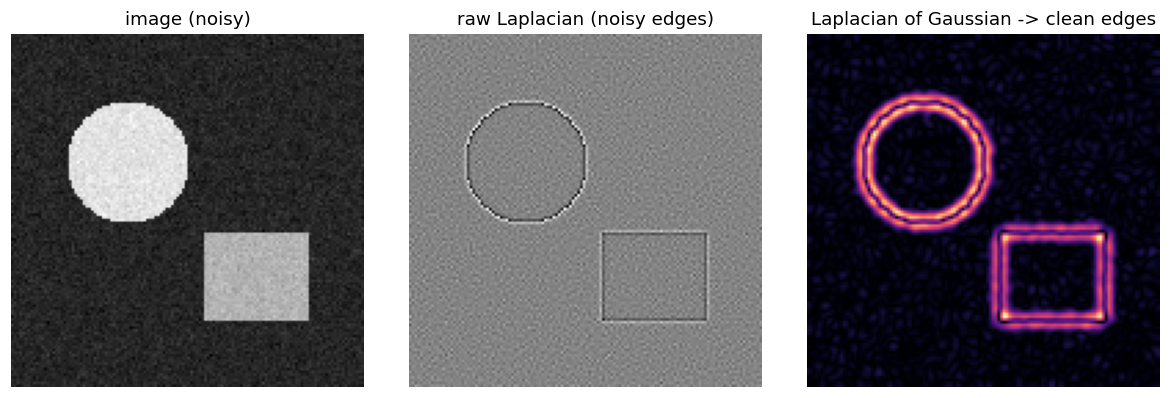

In [ ]:
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)
img = np.zeros((128, 128))
yy, xx = np.mgrid[0:128, 0:128]
img[(xx-42)**2 + (yy-46)**2 < 22**2] = 1.0      # bright disk
img[72:104, 70:108] = 0.75                       # bright square
img += 0.05 * rng.standard_normal(img.shape)     # detector noise

def gaussian_kernel(sigma, size):
    a = np.arange(size) - size//2
    GX, GY = np.meshgrid(a, a)
    g = np.exp(-(GX**2 + GY**2) / (2*sigma**2))
    return g / g.sum()

raw_lap = conv2d(img, LAP)                                   # noisy
blurred = conv2d(img, gaussian_kernel(1.6, 9))
log_edge = conv2d(blurred, LAP)                              # Laplacian of Gaussian

fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
ax[0].imshow(img, cmap="gray");        ax[0].set_title("image (noisy)")
ax[1].imshow(raw_lap, cmap="gray");    ax[1].set_title("raw Laplacian (noisy edges)")
ax[2].imshow(np.abs(log_edge), cmap="magma"); ax[2].set_title("Laplacian of Gaussian -> clean edges")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print("LoG localizes the disk + square boundaries; the noise the blur removed no longer")
print("triggers the second-derivative detector.")

## 4. PhyCV -- when the *physics* does the edge detection
Classical detectors (Laplacian, LoG, Sobel, Canny) are hand-built derivative kernels.
**PhyCV** (the Jalali lab's *Physics-inspired Computer Vision* library -- same lab as
this project's time-stretch / dispersion work) takes a different route: it runs the image
through a *simulated physical process* and reads the answer off the output.

Its flagship is the **Phase Stretch Transform (PST)**: emulate propagating the image
through a diffractive medium with an engineered, frequency-dependent **phase kernel**
$\exp[i\,\phi(\omega)]$ in the 2-D Fourier domain, then take the **phase** of the result
as the edge map. Sharp features (high spatial frequency) accumulate the most phase, so
edges light up -- detection done by dispersion, not by a difference stencil.

Why that should feel familiar: this repo's dispersion operator is the *same kind of
object*. In `dgs/gs_core.disperse` we apply
$$H(\nu)=\exp(i\pi D\,\nu^2)$$
a frequency-domain phase kernel -- a 1-D temporal cousin of PST's 2-D spatial kernel.
Edge detection by PST and phase retrieval by dispersion-GS are two uses of the same
trick: **encode information in an engineered phase, then read it back out.**

Same H = exp(i*phase(freq)) kernel family as gs_core.disperse -- PST detects edges
with it; dispersion-GS retrieves phase with it. One physical idea, two jobs.


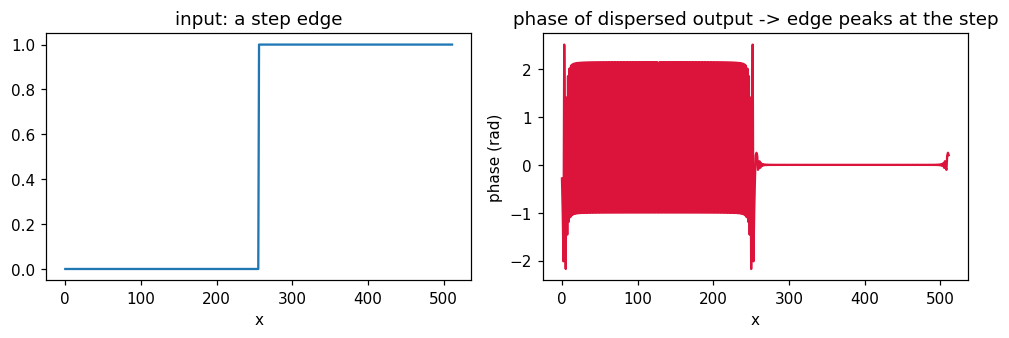

In [ ]:
import matplotlib.pyplot as plt
# A 1-D cartoon of the PST idea: a frequency-dependent phase kernel turns a step edge
# into a localized phase bump. (Real PST is 2-D with a tunable warped phase profile.)
N = 512
sig = np.zeros(N); sig[N//2:] = 1.0                 # a step edge
nu = np.fft.fftfreq(N)
phase_kernel = np.exp(1j * 40.0 * nu**2)            # engineered dispersive phase
out = np.fft.ifft(np.fft.fft(sig) * phase_kernel)
pst_edge = np.angle(out)                            # PST reads the PHASE as the edge map

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(sig); ax[0].set_title("input: a step edge"); ax[0].set_xlabel("x")
ax[1].plot(pst_edge, color="crimson")
ax[1].set_title("phase of dispersed output -> edge peaks at the step")
ax[1].set_xlabel("x"); ax[1].set_ylabel("phase (rad)")
plt.tight_layout(); plt.show()
print("Same H = exp(i*phase(freq)) kernel family as gs_core.disperse -- PST detects edges")
print("with it; dispersion-GS retrieves phase with it. One physical idea, two jobs.")

## Takeaway
- $\nabla^2 = \nabla\cdot\nabla$: gradient, then divergence. In Cartesian it is the sum of
  second partials; on a grid it is convolution with $[[0,1,0],[1,-4,1],[0,1,0]]$.
- It runs every core PDE (Laplace, Poisson, heat, wave, Schrodinger) -- and **the same
  operator** is the classical edge detector (LoG).
- **PhyCV / PST** swaps the difference stencil for an engineered *phase kernel* in the
  Fourier domain -- the very object (`H = exp(i*phase(freq))`) this project uses for
  dispersion and phase retrieval. Edge detection and phase retrieval are the same trick
  pointed at different unknowns.